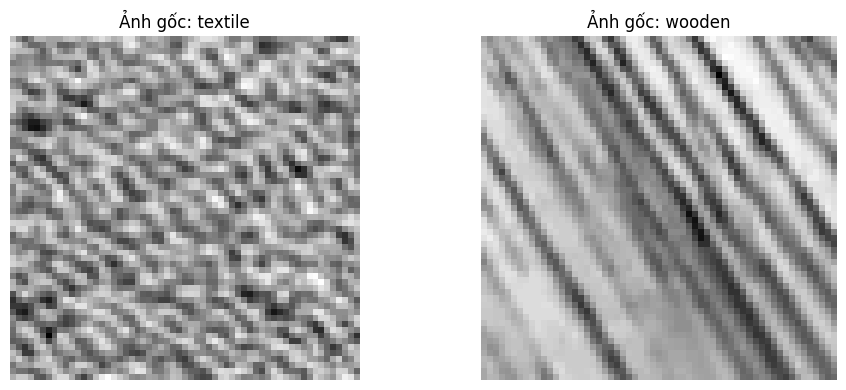

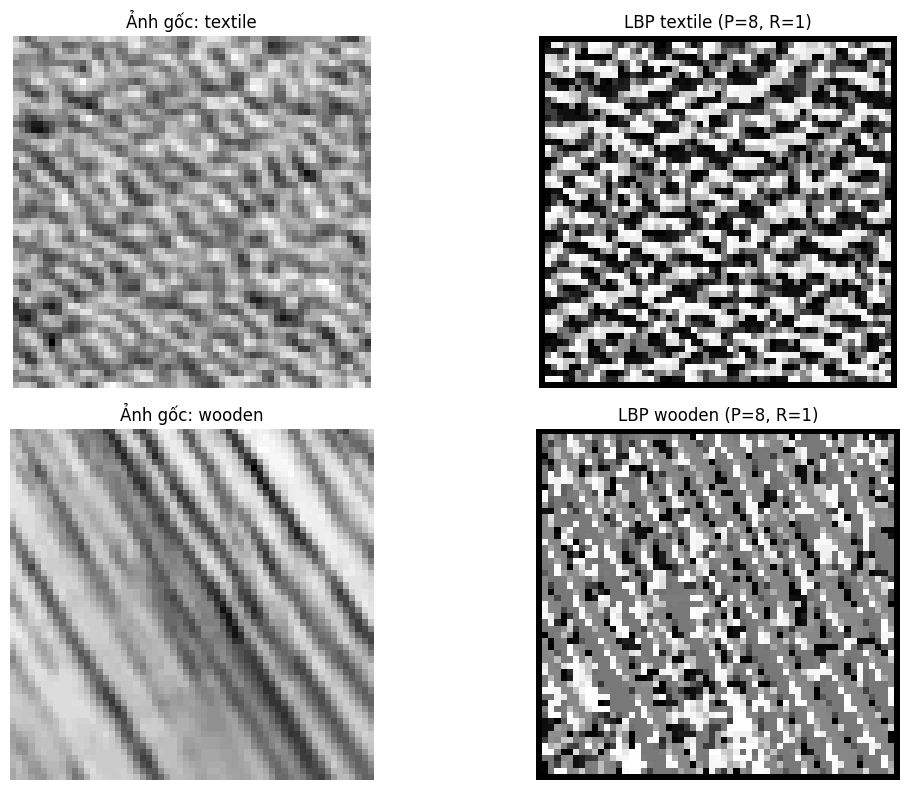

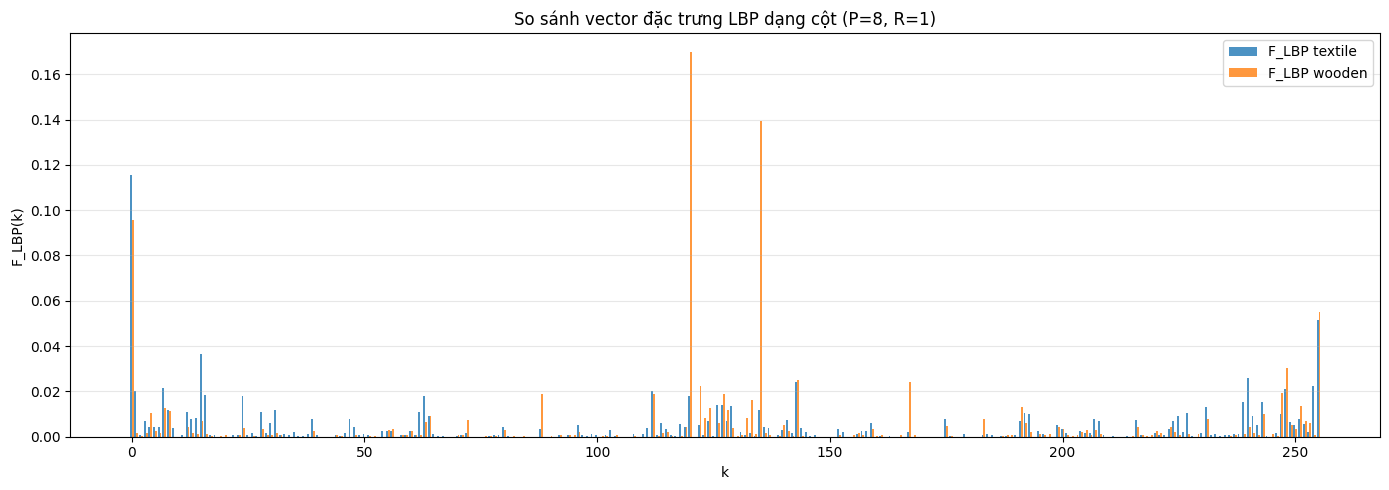

Kích thước ảnh textile: (58, 59)
Kích thước ảnh wooden : (57, 59)
Kích thước ảnh LBP textile: (58, 59)
Kích thước ảnh LBP wooden : (57, 59)
Số phần tử của vector F_LBP: 256
Tổng F_LBP textile: 0.9999999999999999
Tổng F_LBP wooden : 0.9999999999999999
Kiểm tra hoàn tất: ảnh LBP và vector đặc trưng F_LBP được tính hợp lệ.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: Trích chọn đặc trưng kết cấu bằng LBP
# Chương/Mục liên quan: Chương 5 - Đặc trưng thủ công
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa cách tính ảnh LBP(P, R) theo từng điểm ảnh trung tâm.
# - Minh họa cách xây dựng histogram H(k) và vector đặc trưng chuẩn hóa F_LBP(k).
# - So sánh đặc trưng LBP của hai ảnh kết cấu khác nhau.

# Sau khi chạy code, người học cần:
# 1. Quan sát được ảnh LBP sinh ra từ ảnh xám đầu vào.
# 2. Hiểu được cách mã LBP được tạo từ quan hệ giữa điểm lân cận và điểm trung tâm.
# 3. Hiểu được histogram LBP như một vector đặc trưng mô tả kết cấu ảnh.

# Input:
# - Dữ liệu đầu vào: hai ảnh texture từ GitHub
# - Kiểu dữ liệu: ảnh xám

# Output:
# - Ảnh gốc textile và wooden
# - Ảnh LBP tương ứng
# - Biểu đồ so sánh hai vector đặc trưng F_LBP(k)

# Lưu ý
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_gitlab_image(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)

textile_uri = "https://github.com/lthavnu/cv-book/raw/main/images/textile.png"
wooden_uri  = "https://github.com/lthavnu/cv-book/raw/main/images/wooden.png"

I_textile = read_gitlab_image(textile_uri)
I_wooden  = read_gitlab_image(wooden_uri)

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(I_textile, cmap="gray")
plt.title("Ảnh gốc: textile")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(I_wooden, cmap="gray")
plt.title("Ảnh gốc: wooden")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# Hàm tính ảnh LBP(P, R) theo đúng công thức:
# LBP(P, R, I_c) = Σ s(I_p - I_c) * 2^p

def LBP_image(I, P=8, R=1):
    H, W = I.shape
    LBP_PR_Ic = np.zeros((H, W), dtype=np.uint8)

    theta = 2 * np.pi * np.arange(P) / P

    for y in range(R, H - R):
        for x in range(R, W - R):
            I_c = I[y, x]
            lbp_code = 0

            for p in range(P):
                x_p = int(round(x + R * np.cos(theta[p])))
                y_p = int(round(y - R * np.sin(theta[p])))

                I_p = I[y_p, x_p]

                # s(I_p - I_c)
                s = 1 if I_p >= I_c else 0

                # Cộng theo công thức Σ s(.) * 2^p
                lbp_code += s * (2 ** p)

            LBP_PR_Ic[y, x] = lbp_code

    return LBP_PR_Ic

# Hàm tính histogram H(k) và vector đặc trưng chuẩn hóa F_LBP(k)

def extract_F_LBP(I, P=8, R=1):
    LBP_PR_Ic = LBP_image(I, P=P, R=R)

    K = 2 ** P

    H_k, _ = np.histogram(
        LBP_PR_Ic.ravel(),
        bins=np.arange(0, K + 1)
    )

    F_LBP = H_k.astype(np.float32) / np.sum(H_k)

    return LBP_PR_Ic, H_k, F_LBP

# Tham số theo công thức LBP(P, R)

P = 8
R = 1

LBP_textile, H_textile, F_LBP_textile = extract_F_LBP(I_textile, P=P, R=R)
LBP_wooden,  H_wooden,  F_LBP_wooden  = extract_F_LBP(I_wooden,  P=P, R=R)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(I_textile, cmap="gray")
plt.title("Ảnh gốc: textile")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(LBP_textile, cmap="gray")
plt.title(f"LBP textile (P={P}, R={R})")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(I_wooden, cmap="gray")
plt.title("Ảnh gốc: wooden")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(LBP_wooden, cmap="gray")
plt.title(f"LBP wooden (P={P}, R={R})")
plt.axis("off")

plt.tight_layout()
plt.show()

# So sánh hai vector đặc trưng F_LBP(k) bằng biểu đồ cột

k = np.arange(2 ** P)
width = 0.4

plt.figure(figsize=(14, 5))

plt.bar(
    k - width / 2,
    F_LBP_textile,
    width=width,
    label="F_LBP textile",
    alpha=0.8
)

plt.bar(
    k + width / 2,
    F_LBP_wooden,
    width=width,
    label="F_LBP wooden",
    alpha=0.8
)

plt.xlabel("k")
plt.ylabel("F_LBP(k)")
plt.title(f"So sánh vector đặc trưng LBP dạng cột (P={P}, R={R})")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

print("Kích thước ảnh textile:", I_textile.shape)
print("Kích thước ảnh wooden :", I_wooden.shape)

print("Kích thước ảnh LBP textile:", LBP_textile.shape)
print("Kích thước ảnh LBP wooden :", LBP_wooden.shape)

print("Số phần tử của vector F_LBP:", len(F_LBP_textile))
print("Tổng F_LBP textile:", np.sum(F_LBP_textile))
print("Tổng F_LBP wooden :", np.sum(F_LBP_wooden))

assert I_textile.shape == LBP_textile.shape
assert I_wooden.shape == LBP_wooden.shape
assert len(F_LBP_textile) == 2 ** P
assert len(F_LBP_wooden) == 2 ** P
assert np.isclose(np.sum(F_LBP_textile), 1.0)
assert np.isclose(np.sum(F_LBP_wooden), 1.0)

print("Kiểm tra hoàn tất: ảnh LBP và vector đặc trưng F_LBP được tính hợp lệ.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi R từ 1 sang 2 hoặc 3 để quan sát ảnh hưởng của bán kính lân cận.
# 2. Thay đổi P từ 8 sang 4 để thấy số mã LBP giảm từ 256 xuống 16.
# 3. Thử thay ảnh texture khác để kiểm tra khả năng phân biệt kết cấu của histogram LBP.